# Deep learning for computer vision


This notebook will teach you to build and train convolutional networks for image recognition. Brace yourselves.

# CIFAR dataset
This week, we shall focus on the image recognition problem on cifar10 dataset
* 60k images of shape 3x32x32
* 10 different classes: planes, dogs, cats, trucks, etc.

<img src="https://github.com/yandexdataschool/deep_vision_and_graphics/blob/fall22/week02-convnets/cifar10.jpg?raw=1" style="width:80%">

In [17]:
# **IMPORTANT** when running in colab, un-comment this
!wget https://raw.githubusercontent.com/yandexdataschool/Practical_DL/refs/heads/fall25/week03_convnets/cifar.py

--2025-11-04 17:46:56--  https://raw.githubusercontent.com/yandexdataschool/Practical_DL/refs/heads/fall25/week03_convnets/cifar.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8001::154, 2606:50c0:8002::154, 2606:50c0:8000::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8001::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2396 (2.3K) [text/plain]
Saving to: ‘cifar.py.6’

cifar.py.6          100%[===================>]   2.34K  --.-KB/s    in 0s      

2025-11-04 17:46:57 (26.9 MB/s) - ‘cifar.py.6’ saved [2396/2396]



In [18]:
import numpy as np
from cifar import load_cifar10
X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'])

print(X_train.shape,y_train.shape)

(40000, 3, 32, 32) (40000,)


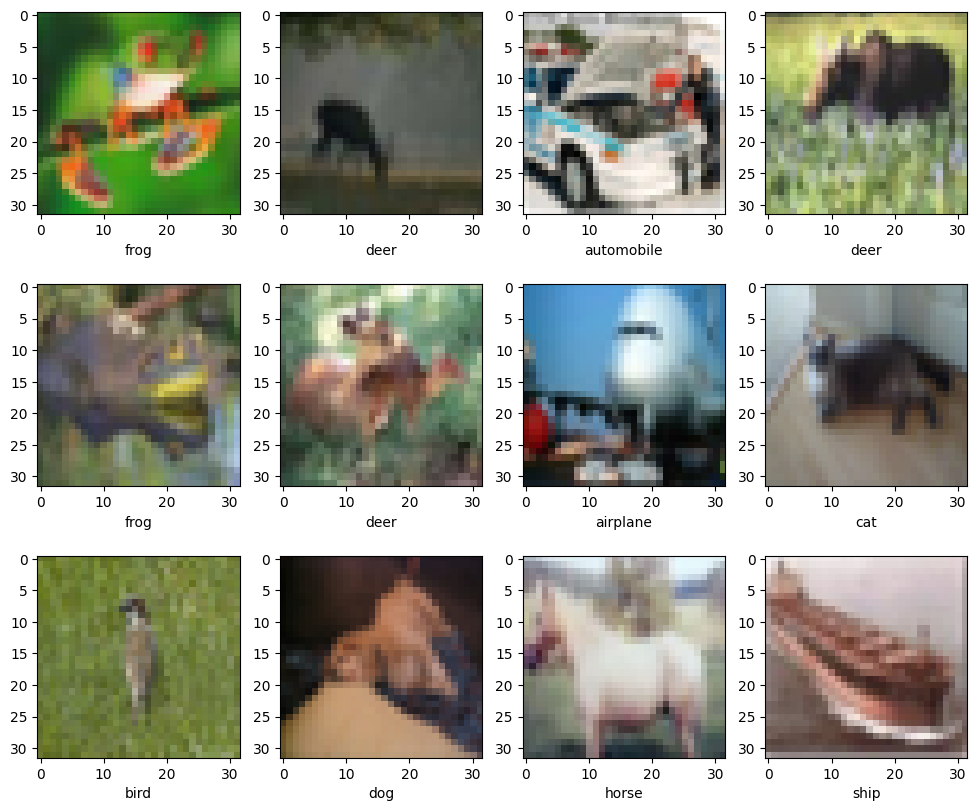

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.xlabel(class_names[y_train[i]])
    plt.imshow(np.transpose(X_train[i],[1,2,0]))

# Building a network

Simple neural networks with layers applied on top of one another can be implemented as `torch.nn.Sequential` - just add a list of pre-built modules and let it train.

Let's start with a dense network for our baseline, then gradually improve it.

In [303]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = "cuda" if torch.cuda.is_available() else "cpu"

# [batch, 3, 32, 32]
model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=(3, 3), padding=1),   # [32, 30, 30]
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d((3, 3)),                   # [32, 15, 15]

    nn.Conv2d(32, 64, kernel_size=(5, 5), padding=1),  # [64, 13, 13]
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d((2, 2)),                   # [64, 6, 6]

    nn.Flatten(),  # reshape images to vectors; if you have conv / pool layers, they go BEFORE flatten
    nn.Linear(1024, 2048),
    nn.ReLU(),
    nn.Linear(2048, 10), # logits for 10 classes. No softmax - this is intentional
).to(device)

device

'cuda'

As in our basic tutorial, we train our model with negative log-likelihood aka crossentropy.

In [301]:
def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32, device=device)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64, device=device)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

In [304]:
# example
compute_loss(X_train[:5], y_train[:5])

tensor(2.4103, device='cuda:0', grad_fn=<MeanBackward0>)

### Training on minibatches
* We got 40k images, that's way too many for a full-batch SGD. Let's train on minibatches instead
* Below is a function that splits the training sample into minibatches

In [305]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss = []
val_accuracy = []

# An auxilary function that returns mini-batches for neural network training
def iterate_minibatches(X, y, batchsize):
    indices = np.random.permutation(np.arange(len(X)))
    for start in range(0, len(indices), batchsize):
        ix = indices[start: start + batchsize]
        yield X[ix], y[ix]

In [306]:
import time
from tqdm import tqdm
num_epochs = 100 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one Optimiser iteration

best_accuracy=0
for epoch in tqdm(range(num_epochs)):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item())  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32, device=device))
            y_pred = logits.argmax(-1).detach().to("cpu").numpy()
            val_accuracy.append(np.mean(y_batch == y_pred))

    current_accuracy = np.mean(val_accuracy[-len(X_val) // batch_size :])
    if current_accuracy > best_accuracy:
      print(f"Current best accuracy = {np.round(current_accuracy,4)}")
      best_accuracy = current_accuracy
      best_epoch = epoch
      torch.save(model.state_dict(), "best_state.pt")
    if epoch - best_epoch > 20:
      break # early stopping

  1%|          | 1/100 [00:01<02:55,  1.77s/it]

Current best accuracy = 0.5753


  2%|▏         | 2/100 [00:03<02:52,  1.76s/it]

Current best accuracy = 0.6795


  3%|▎         | 3/100 [00:05<02:51,  1.77s/it]

...

  7%|▋         | 7/100 [00:12<02:42,  1.75s/it]

Current best accuracy = 0.7455


  9%|▉         | 9/100 [00:15<02:37,  1.73s/it]

Current best accuracy = 0.7551


 29%|██▉       | 29/100 [00:52<02:07,  1.80s/it]


Don't wait for full 100 epochs. You can interrupt training after 5-20 epochs once validation accuracy stops going up.

### Final test

In [307]:
model.load_state_dict(torch.load("best_state.pt"))

model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32, device=device))
    y_pred = logits.max(1)[1].data.cpu().numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		75.00 %
Achievement unlocked: 80lvl Warlock!


## Task I: small convolution net
### First step

Let's create a mini-convolutional network with roughly such architecture:
* Input layer
* 3x3 convolution with 10 filters and _ReLU_ activation
* 2x2 pooling (or set previous convolution stride to 3)
* Flatten
* Dense layer with 100 neurons and _ReLU_ activation
* 10% dropout
* Output dense layer.


__Convolutional layers__ in torch are just like all other layers, but with a specific set of parameters:

__`...`__

__`model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)) # convolution`__

__`model.add_module('pool1', nn.MaxPool2d(2)) # max pooling 2x2`__

__`...`__


Once you're done (and compute_loss no longer raises errors), train it with __Adam__ optimizer with default params (feel free to modify the code above).

If everything is right, you should get at least __50%__ validation accuracy.

__Hint:__ If you don't want to compute shapes by hand, just plug in any shape (e.g. 1 unit) and run compute_loss. You will see something like this:

__`RuntimeError: size mismatch, m1: [5 x 1960], m2: [1 x 64] at /some/long/path/to/torch/operation`__

See the __1960__ there? That's your actual input shape.

## Task 2: adding normalization

* Add batch norm (with default params) between convolution and ReLU
  * nn.BatchNorm*d (1d for dense, 2d for conv)
  * usually better to put them after linear/conv but before nonlinearity
* Re-train the network with the same optimizer, it should get at least 60% validation accuracy at peak.



## Task 3: Data Augmentation

There's a powerful torch tool for image preprocessing useful to do data preprocessing and augmentation.

Here's how it works: we define a pipeline that
* makes random crops of data (augmentation)
* randomly flips image horizontally (augmentation)
* then normalizes it (preprocessing)

In [370]:
from torchvision import transforms
means = np.array((0.4914, 0.4822, 0.4465))  # statistics from dataset documentation
stds = np.array((0.2023, 0.1994, 0.2010))

transform_augment = transforms.Compose([
    # transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation([-30, 30]),
    # transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

In [371]:
from torchvision.datasets import CIFAR10
train_loader = CIFAR10("./cifar_data/", train=True, transform=transform_augment)

train_dataloader = torch.utils.data.DataLoader(
    train_loader,  batch_size=32, shuffle=True, num_workers=20)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


X: <class 'torch.Tensor'> torch.Size([32, 3, 32, 32])
y: <class 'torch.Tensor'> torch.Size([32])


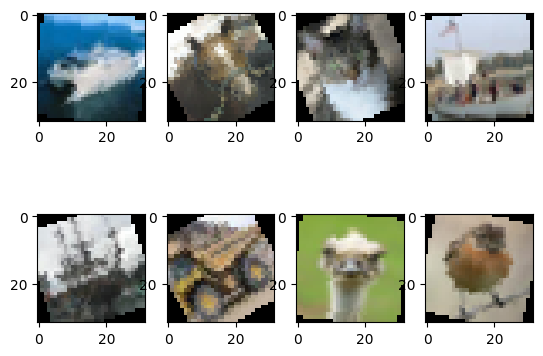

In [372]:
for (x_batch, y_batch) in train_dataloader:

    print('X:', type(x_batch), x_batch.shape)
    print('y:', type(y_batch), y_batch.shape)

    for i, img in enumerate(x_batch.numpy()[:8]):
        plt.subplot(2, 4, i+1)
        plt.imshow(img.transpose([1,2,0]) * stds + means )

    break

    raise NotImplementedError("Please use this code in your training loop")
    # TODO use this in your training loop

In [373]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = "cuda" if torch.cuda.is_available() else "cpu"

# [batch, 3, 32, 32]
model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=(3, 3), padding=1),   # [32, 30, 30]
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d((3, 3)),                   # [32, 15, 15]

    nn.Conv2d(32, 64, kernel_size=(5, 5), padding=1),  # [64, 13, 13]
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d((2, 2)),                   # [64, 6, 6]

    nn.Flatten(),  # reshape images to vectors; if you have conv / pool layers, they go BEFORE flatten
    nn.Linear(1024, 2048),
    nn.ReLU(),
    nn.Linear(2048, 10), # logits for 10 classes. No softmax - this is intentional
).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

In [374]:
import time
from tqdm import tqdm
import numpy as np
import torch

num_epochs = 100
batch_size = 32

best_accuracy = 0
for epoch in tqdm(range(num_epochs)):
    start_time = time.time()
    model.train(True)
    
    # Training loop
    for X_batch, y_batch in train_dataloader:
        # Move batch to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)  # y_batch is already a tensor!
        
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item())

    # Validation loop - use VALIDATION dataloader, not training!
    model.train(False)
    val_accuracy_batch = []
    with torch.no_grad():
        for X_batch, y_batch in train_dataloader:  # Use val_dataloader here
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits = model(X_batch)
            y_pred = logits.argmax(-1).cpu().numpy()
            y_true = y_batch.cpu().numpy()
            val_accuracy_batch.append(np.mean(y_true == y_pred))

    current_accuracy = np.mean(val_accuracy_batch)
    if current_accuracy > best_accuracy:
        print(f"Current best accuracy = {np.round(current_accuracy,4)}")
        best_accuracy = current_accuracy
        best_epoch = epoch
        torch.save(model.state_dict(), "best_state_2nd_step.pt")
    if epoch - best_epoch > 20:
        break

  1%|          | 1/100 [00:11<19:34, 11.86s/it]

Current best accuracy = 0.5633


  2%|▏         | 2/100 [00:23<18:57, 11.61s/it]

Current best accuracy = 0.6086


  3%|▎         | 3/100 [00:35<19:19, 11.96s/it]

...

Current best accuracy = 0.97


 99%|█████████▉| 99/100 [19:24<00:08,  8.43s/it]

Current best accuracy = 0.9715


100%|██████████| 100/100 [19:34<00:00, 11.74s/it]

Current best accuracy = 0.9737


When testing, we don't need random crops, just normalize with same statistics.

In [384]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

test_loader = CIFAR10("./cifar_data/", train=False, transform=transform_test)
test_data_loader = torch.utils.data.DataLoader(test_loader, batch_size=32, shuffle=True, num_workers=20)

model.load_state_dict(torch.load("best_state_2nd_step.pt"))

model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in test_data_loader:
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32, device=device))
    y_pred = logits.max(1)[1].data.cpu().numpy()
    test_batch_acc.append(np.mean(y_batch.cpu().numpy() == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		75.43 %
Achievement unlocked: 80lvl Warlock!


# Homework 2.2: The Quest For A Better Network

In this assignment you will build a monster network to solve CIFAR10 image classification.

This notebook is intended as a sequel to seminar 3, please give it a try if you haven't done so yet.

(please read it at least diagonally)

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.
* There is a __mini-report__ at the end that you will have to fill in. We recommend reading it first and filling it while you iterate.

## Grading
* starting at zero points
* +20% for describing your iteration path in a report below.
* +20% for building a network that gets above 20% accuracy
* +10% for beating each of these milestones on __TEST__ dataset:
    * 50% (50% points)
    * 60% (60% points)
    * 65% (70% points)
    * 70% (80% points)
    * 75% (90% points)
    * 80% (full points)
    
## Restrictions
* Please do NOT use pre-trained networks for this assignment until you reach 80%.
 * In other words, base milestones must be beaten without pre-trained nets (and such net must be present in the e-mail). After that, you can use whatever you want.
* you __can__ use validation data for training, but you __can't'__ do anything with test data apart from running the evaluation procedure.

## Tips on what can be done:


 * __Network size__
   * MOAR neurons,
   * MOAR layers, ([torch.nn docs](http://pytorch.org/docs/master/nn.html))

   * Nonlinearities in the hidden layers
     * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

   * Ph'nglui mglw'nafh Cthulhu R'lyeh wgah'nagl fhtagn!


### The main rule of prototyping: one change at a time
   * By now you probably have several ideas on what to change. By all means, try them out! But there's a catch: __never test several new things at once__.


### Optimization
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum
   * You should certainly use adaptive optimizers
     * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (nn.BatchNorm2d) for the win!
     * Sometimes more batch normalization is better.
   * __Regularize__ to prevent overfitting
     * Add some L2 weight norm to the loss function, PyTorch will do the rest
       * Can be done manually or with weight_decay parameter of a optimizer ([for example SGD's doc](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD)).
     * Dropout (`nn.Dropout`) - to prevent overfitting
       * Don't overdo it. Check if it actually makes your network better
   
### Convolution architectures
   * This task __can__ be solved by a sequence of convolutions and poolings with batch_norm and ReLU seasoning, but you shouldn't necessarily stop there.
   * [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions (exotic)](https://arxiv.org/abs/1608.06993), [Capsule networks (exotic)](https://arxiv.org/abs/1710.09829)
   * Please do try a few simple architectures before you go for resnet-152.
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment that you try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   
### Data augmemntation
   * getting 5x as large dataset for free is a great
     * Zoom-in+slice = move
     * Rotate+zoom(to remove black stripes)
     * Add Noize (gaussian or bernoulli)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
     * Other cool libraries: cv2, skimake, PIL/Pillow
   * A more advanced way is to use torchvision transforms:
    ```
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    trainset = torchvision.datasets.CIFAR10(root=path_to_cifar_like_in_seminar, train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    ```
   * Or use this tool from Keras (requires theano/tensorflow): [tutorial](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), [docs](https://keras.io/preprocessing/image/)
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.
   
```

```

```

```

```

```

```

```


## Iteration path:

#### Iteration 1.
1. Applied batch normalisation to each convolutional layer;
2. Added 3rd convolutional layer;
3. Added one more dense layer;

That helped a lot, but 72% reached at max (on 1st cifar dataset)


#### Iteration 2.
4. Removed 3 conv layer and dense layer;
5. Changed kernel size of 2nd conv layer;
6. Added lr=1e-3 for Adam optimizer;

Reached 75% on 1st cifar TEST dataset. 


#### Iteration 3.
7. Applied default data augmentation. Didn't reach 70% on large CIFAR dataset;
8. Modified augmentation - removed crop and horizontal flips.

Reached 75% on large dataset.